In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn import set_config

In [2]:
set_config(transform_output="pandas")

# Load the data

In [3]:
df = pd.read_csv("../data/customer_churn_processed_data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      10000 non-null  int64  
 1   country          10000 non-null  object 
 2   gender           10000 non-null  object 
 3   age              10000 non-null  int64  
 4   tenure           10000 non-null  int64  
 5   balance          10000 non-null  float64
 6   numofproducts    10000 non-null  int64  
 7   hascrcard        10000 non-null  int64  
 8   isactivemember   10000 non-null  int64  
 9   estimatedsalary  10000 non-null  float64
 10  exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


### Split the data

In [5]:
X = df.drop("exited", axis=1)
y = df["exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [6]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape, sep="\n")

(8000, 10)
(8000,)
(2000, 10)
(2000,)


In [7]:
y_train.value_counts(normalize=True)

exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

In [8]:
y_test.value_counts(normalize=True)

exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64

### Define categorical transformer

In [9]:
category_transformer = ColumnTransformer(
    [
        (
            "cat_encoder",
            OneHotEncoder(sparse_output=False, drop="if_binary"),
            ["country", "gender"],
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

### Define utility functions and tables

In [10]:
def get_errors(estimator, X, y):
    preds = estimator.predict(X)
    accuracy = accuracy_score(y, preds)
    recall = recall_score(y, preds)
    precision = precision_score(y, preds, zero_division=0.0)
    return {"accuracy": accuracy, "recall": recall, "precision": precision}


def get_avg_cv_errors(cv_result):
    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
    }

def plot_confusion_matrix(estimator, model_name, X_train, X_test, y_train, y_test):
    ConfusionMatrixDisplay.from_estimator(estimator, X_train, y_train)
    plt.title(f"Confusion Matrix of {model_name} Model [Training Set]");

    ConfusionMatrixDisplay.from_estimator(estimator, X_test, y_test)
    plt.title(f"Confusion Matrix of {model_name} Model [Test Set]");

In [11]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "test_accuracy",
        "test_recall",
        "test_precision"
    ]
)

In [12]:
def log_error(model_name, errors, eval_set):
    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision")]
    perf_df.loc[model_name, cols] = list(errors)

### Build and Evaluate Baseline Model

In [13]:
base_model = DummyClassifier()  # Instantiate the model
base_model.fit(X_train, y_train)  # Train the model

DummyClassifier()

In [14]:
train_pred = base_model.predict(X_train)  # Generate train prediction

In [15]:
train_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [16]:
# Evaluate training predictions

base_train_errors = get_errors(base_model, X_train, y_train)
base_train_errors

{'accuracy': 0.79625, 'recall': np.float64(0.0), 'precision': np.float64(0.0)}

In [17]:
# Log train error
log_error("Base Model", base_train_errors.values(), "train")

In [18]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


#### Get cross validation error

In [19]:
cv_results = cross_validate(base_model, X_train, y_train, cv=5, scoring=get_errors)

In [20]:
cv_results

{'fit_time': array([0.00450921, 0.00373483, 0.00308394, 0.0031364 , 0.00411677]),
 'score_time': array([0.01301455, 0.01221371, 0.01263809, 0.01229954, 0.01787472]),
 'test_accuracy': array([0.79625, 0.79625, 0.79625, 0.79625, 0.79625]),
 'test_recall': array([0., 0., 0., 0., 0.]),
 'test_precision': array([0., 0., 0., 0., 0.])}

In [21]:
base_avg_cv_errors = get_avg_cv_errors(cv_results)
base_avg_cv_errors

{'accuracy': np.float64(0.79625),
 'recall': np.float64(0.0),
 'precision': np.float64(0.0)}

In [22]:
log_error("Base Model", base_avg_cv_errors.values(), "cv")

In [23]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,NaN,NaN,NaN


#### Evaluate model on test set

In [24]:
test_pred = base_model.predict(X_test)

In [25]:
base_test_errors = get_errors(base_model, X_test, y_test)
base_test_errors

{'accuracy': 0.7965, 'recall': np.float64(0.0), 'precision': np.float64(0.0)}

#### Save base model error

In [26]:
log_error("Base Model", base_test_errors.values(), "test")

In [27]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0


### Plot base model confusion matrix

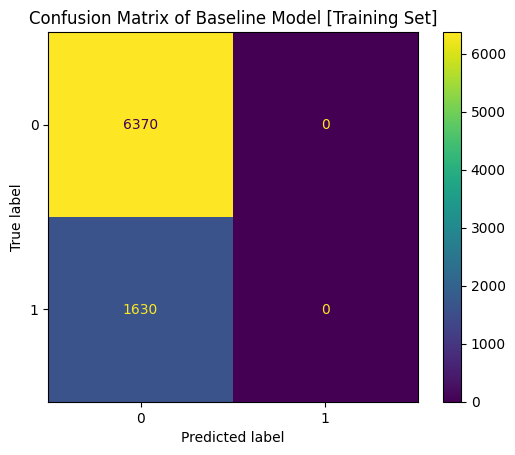

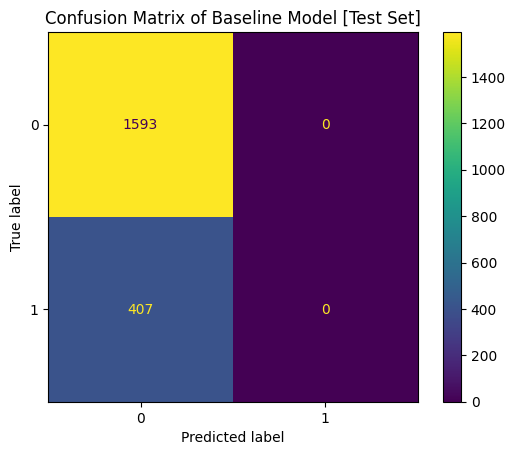

In [28]:
plot_confusion_matrix(base_model, "Baseline", X_train, X_test, y_train, y_test)

### Build and Evaluate Logistic Regression Model

In [29]:
lr_model = LogisticRegression(max_iter=10000)

In [30]:
pipeline = make_pipeline(category_transformer, lr_model)

Train the model

In [31]:
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression(max_iter=10000))])

Evaluate the model

In [32]:
train_preds = pipeline.predict(X_train)

In [33]:
lr_train_errors = get_errors(pipeline, X_train, y_train)
lr_train_errors

{'accuracy': 0.810875,
 'recall': np.float64(0.2147239263803681),
 'precision': np.float64(0.6003430531732419)}

Get cross validation result

In [34]:
cv_results = cross_validate(pipeline, X_train, y_train, cv=5, scoring=get_errors)

In [35]:
lr_avg_cv_errors = get_avg_cv_errors(cv_results)
lr_avg_cv_errors

{'accuracy': np.float64(0.810125),
 'recall': np.float64(0.21349693251533744),
 'precision': np.float64(0.5952394987379659)}

Evaluate the model on the test set

In [36]:
lr_test_errors = get_errors(pipeline, X_test, y_test)
lr_test_errors

{'accuracy': 0.8075,
 'recall': np.float64(0.18427518427518427),
 'precision': np.float64(0.5859375)}

#### Log errors

In [37]:
log_error("LR Model", lr_train_errors.values(), "train")
log_error("LR Model", lr_avg_cv_errors.values(), "cv")
log_error("LR Model", lr_test_errors.values(), "test")

In [38]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938


### Plot LR model confusion matrix

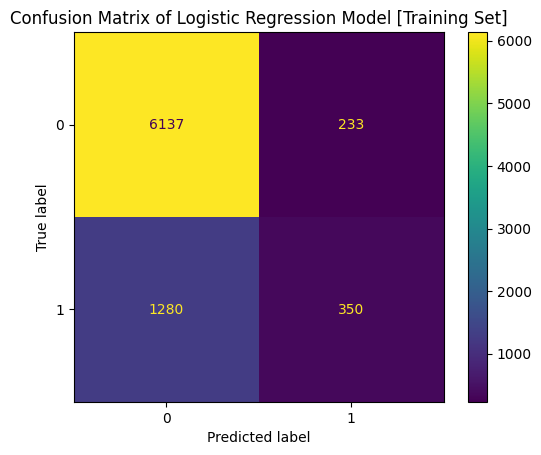

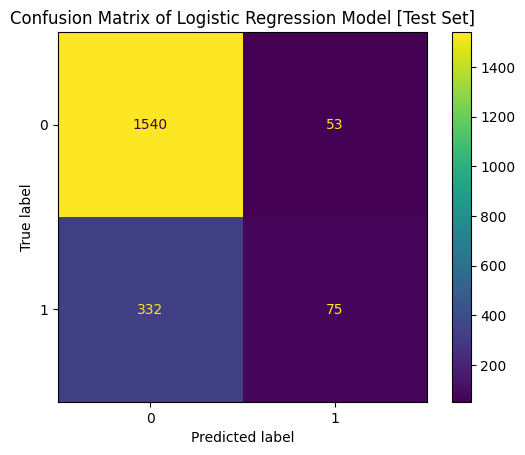

In [39]:
plot_confusion_matrix(pipeline, "Logistic Regression", X_train, X_test, y_train, y_test)

### Build and Evaluate Decision Tree Model

#### Build the model

In [40]:
# Instantiate the model

dt_model = DecisionTreeClassifier(random_state=42)

In [41]:
# Create pipeline

pipeline = make_pipeline(category_transformer, dt_model)
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

#### Evaluate the training set

In [42]:
dt_train_error = get_errors(pipeline, X_train, y_train)
dt_train_error

{'accuracy': 1.0, 'recall': np.float64(1.0), 'precision': np.float64(1.0)}

#### Evaluate with cross validation

In [43]:
cv_results = cross_validate(
    pipeline, X_train, y_train, scoring=["accuracy", "precision", "recall"], cv=5
)
cv_results

{'fit_time': array([0.12163353, 0.1130569 , 0.08542609, 0.08404231, 0.08280683]),
 'score_time': array([0.02632499, 0.0171535 , 0.02418923, 0.01964021, 0.02153659]),
 'test_accuracy': array([0.790625, 0.789375, 0.78625 , 0.785   , 0.7925  ]),
 'test_precision': array([0.48753463, 0.48348348, 0.47619048, 0.47428571, 0.49117647]),
 'test_recall': array([0.5398773 , 0.49386503, 0.49079755, 0.50920245, 0.51226994])}

In [44]:
dt_avg_cv_error = get_avg_cv_errors(cv_results)
dt_avg_cv_error

{'accuracy': np.float64(0.7887500000000001),
 'recall': np.float64(0.50920245398773),
 'precision': np.float64(0.4825341541173381)}

#### Evaluate on test

In [45]:
dt_test_error = get_errors(pipeline, X_test, y_test)
dt_test_error

{'accuracy': 0.786,
 'recall': np.float64(0.5110565110565111),
 'precision': np.float64(0.4759725400457666)}

#### Handle the overfitting issue in the decision tree

In [46]:
# Check the tree's depth

pipeline[-1].get_depth()

24

#### Find the optimal tree depth with grid search cv

In [47]:
param_grid = {"decisiontreeclassifier__max_depth": range(2, 24)}

grid_search_cv = GridSearchCV(
    pipeline, param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"], refit="recall",
    return_train_score=True
)
grid_search_cv.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat_encoder',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       sparse_output=False),
                                                                         ['country',
                                                                          'gender'])],
                                                          verbose_feature_names_out=False)),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid={'decisiontreeclassifier__max_depth': range(2, 24)},
             refit='recall', return_train_score=True,
             scoring=['accuracy', 'recall', 'precision'])

In [48]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,mean_train_precision,std_train_precision
0,0.070523,0.034850,0.034641,0.018265,2,{'decisiontreeclassifier__max_depth': 2},0.824375,0.841875,0.821250,0.827500,...,0.626467,0.045625,8,0.615385,0.681404,0.615957,0.611828,0.603854,0.625686,0.028192
1,0.040405,0.002399,0.022133,0.001676,3,{'decisiontreeclassifier__max_depth': 3},0.843750,0.846250,0.833125,0.836875,...,0.790784,0.059099,1,0.844498,0.693548,0.862233,0.804554,0.865285,0.814024,0.064007
2,0.059260,0.016456,0.030281,0.010925,4,{'decisiontreeclassifier__max_depth': 4},0.848125,0.853750,0.839375,0.838750,...,0.768770,0.040963,4,0.808696,0.794408,0.813559,0.780186,0.737430,0.786856,0.027329
3,0.060606,0.009681,0.032020,0.002022,5,{'decisiontreeclassifier__max_depth': 5},0.848125,0.856875,0.842500,0.840625,...,0.782458,0.057202,3,0.887295,0.810726,0.781818,0.788352,0.780664,0.809771,0.040245
4,0.060065,0.010092,0.032569,0.009927,6,{'decisiontreeclassifier__max_depth': 6},0.852500,0.870000,0.843750,0.841875,...,0.782881,0.041155,2,0.839063,0.830133,0.840841,0.830460,0.780178,0.824135,0.022406


In [49]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "std_test_recall",
    "mean_train_recall",
    "std_train_recall",
    "rank_test_recall",
    "mean_test_accuracy",
    "mean_train_accuracy",
    "mean_test_precision",
    "mean_train_precision",
]

In [50]:
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall", "std_test_recall"])

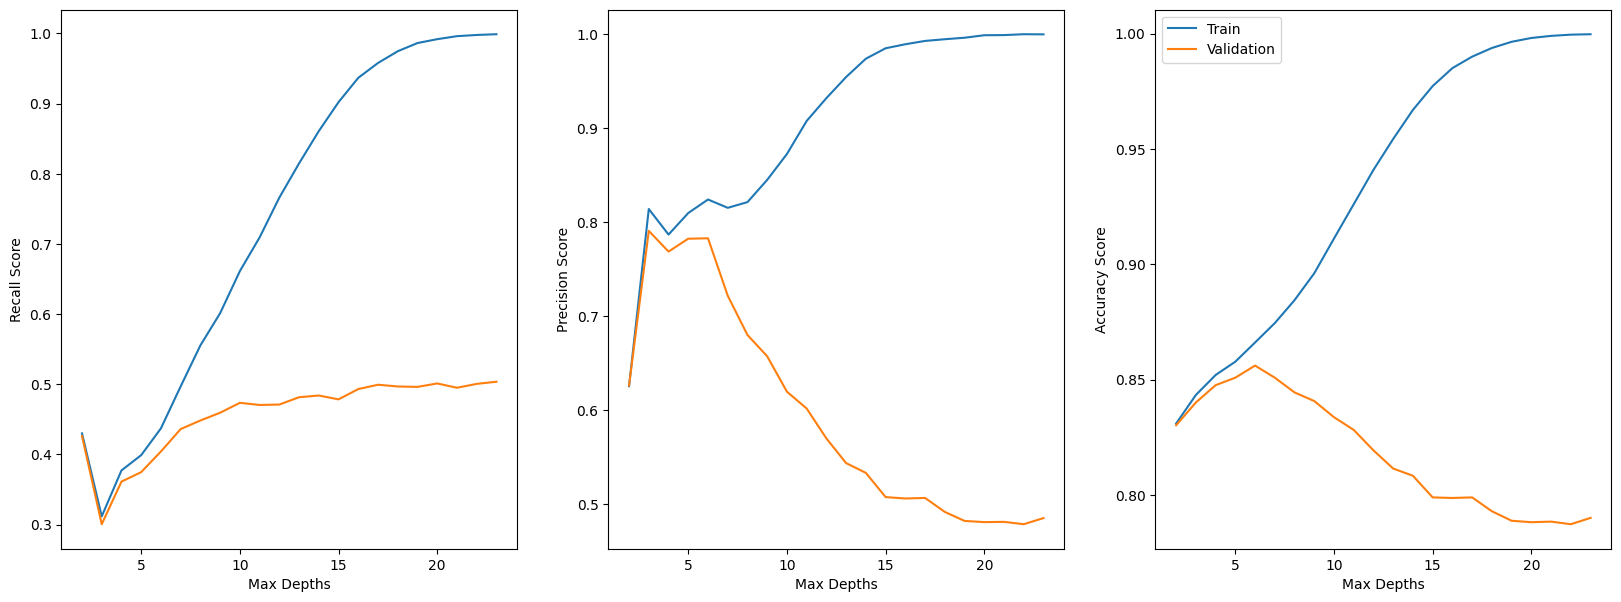

In [51]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [52]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[5, 6, 7, 8]]

,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall,rank_test_recall,mean_test_accuracy,mean_train_accuracy,mean_test_precision,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,
5,0.374847,0.035317,0.399080,0.035626,20,0.850875,0.857812,0.782458,0.809771
6,0.404294,0.052288,0.437270,0.019560,19,0.856125,0.866125,0.782881,0.824135
7,0.436196,0.028736,0.497086,0.009909,17,0.850875,0.874531,0.721900,0.815286
8,0.448466,0.048710,0.555521,0.027077,16,0.844500,0.884469,0.680113,0.821352


We choose the best max depth as 6 because it is optimal for both accuracy and precision at that point. If we choose the max depth for the best average recall on the validation set, we would the be overfitting the other metrics.

#### Retrain the model with max_depth of 6

In [53]:
# Instantiate the model

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)

In [54]:
# Create pipeline

pipeline = make_pipeline(category_transformer, dt_model)
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

#### Evaluate the training set

In [55]:
dt6_train_errors = get_errors(pipeline, X_train, y_train)
dt6_train_errors

{'accuracy': 0.868125,
 'recall': np.float64(0.45950920245398774),
 'precision': np.float64(0.8114842903575298)}

#### Cross validate

In [56]:
cv_results = cross_validate(pipeline, X_train, y_train, cv=5, scoring=["accuracy", "recall", "precision"], n_jobs=-1)
dt6_avg_cv_errors = get_avg_cv_errors(cv_results)
dt6_avg_cv_errors

{'accuracy': np.float64(0.8561250000000001),
 'recall': np.float64(0.40429447852760736),
 'precision': np.float64(0.7828812283541768)}

#### Evaluate on test

In [57]:
dt6_test_errors = get_errors(pipeline, X_test, y_test)
dt6_test_errors

{'accuracy': 0.8595,
 'recall': np.float64(0.44226044226044225),
 'precision': np.float64(0.7692307692307693)}

#### Log errors

In [58]:
log_error("DT Model", dt6_train_errors.values(), "train")
log_error("DT Model", dt6_avg_cv_errors.values(), "cv")
log_error("DT Model", dt6_test_errors.values(), "test")

In [59]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938
DT Model,0.868125,0.459509,0.811484,0.856125,0.404294,0.782881,0.8595,0.44226,0.769231


### Plot DT model confusion matrix

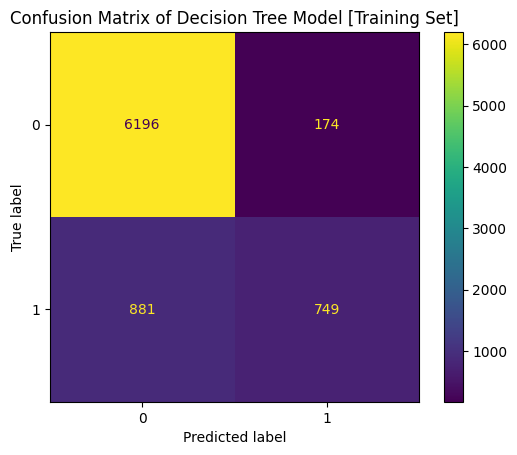

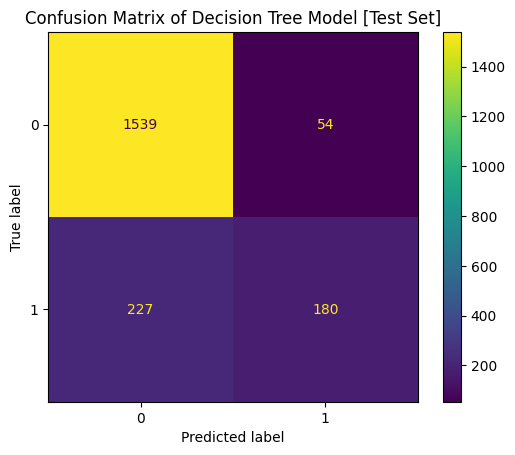

In [60]:
plot_confusion_matrix(pipeline, "Decision Tree", X_train, X_test, y_train, y_test)

### Random Forest

#### Build the model

In [61]:
# Instantiate the model

rf_model = RandomForestClassifier(max_depth=6, random_state=42)

In [62]:
# Create pipeline

pipeline = make_pipeline(category_transformer, rf_model)
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=6, random_state=42))])

#### Evaluate the training set

In [63]:
rf_train_errors = get_errors(pipeline, X_train, y_train)
rf_train_errors

{'accuracy': 0.867,
 'recall': np.float64(0.3993865030674847),
 'precision': np.float64(0.8845108695652174)}

#### Evaluate with cross validation

In [64]:
cv_results = cross_validate(pipeline, X_train, y_train, scoring=["accuracy", "precision", "recall"], cv=5)
rf_avg_cv_errors = get_avg_cv_errors(cv_results)
rf_avg_cv_errors

{'accuracy': np.float64(0.8578749999999999),
 'recall': np.float64(0.38343558282208584),
 'precision': np.float64(0.8268908821453659)}

#### Evaluate on test

In [65]:
rf_test_errors = get_errors(pipeline, X_test, y_test)
rf_test_errors

{'accuracy': 0.8605,
 'recall': np.float64(0.37346437346437344),
 'precision': np.float64(0.8636363636363636)}

#### Log errors

In [66]:
log_error("RF Model", rf_train_errors.values(), "train")
log_error("RF Model", rf_avg_cv_errors.values(), "cv")
log_error("RF Model", rf_test_errors.values(), "test")

In [67]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938
DT Model,0.868125,0.459509,0.811484,0.856125,0.404294,0.782881,0.8595,0.44226,0.769231
RF Model,0.867,0.399387,0.884511,0.857875,0.383436,0.826891,0.8605,0.373464,0.863636


### Plot RF model confusion matrix

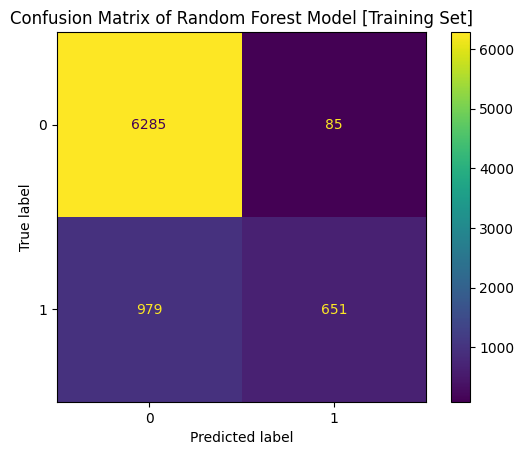

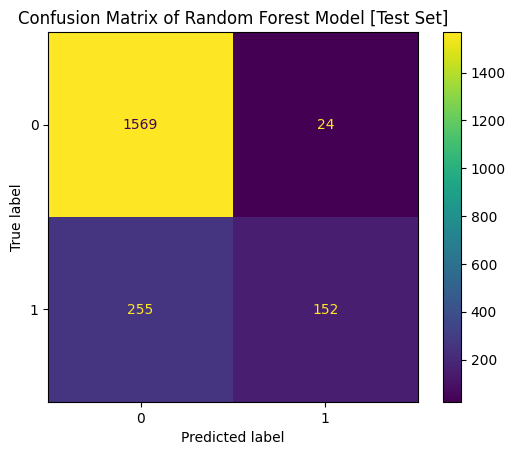

In [68]:
plot_confusion_matrix(pipeline, "Random Forest", X_train, X_test, y_train, y_test)

### Gradient Boosting

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

#### Build the model

In [70]:
# Instantiate the model

gb_model = GradientBoostingClassifier(max_depth=6, random_state=42)

In [71]:
# Create pipeline

pipeline = make_pipeline(category_transformer, gb_model)
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=6, random_state=42))])

#### Evaluate the training set

In [72]:
gb_train_errors = get_errors(pipeline, X_train, y_train)
gb_train_errors

{'accuracy': 0.923625,
 'recall': np.float64(0.6723926380368098),
 'precision': np.float64(0.9343563512361467)}

#### Evaluate with cross validation

In [73]:
cv_results = cross_validate(pipeline, X_train, y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.86),
 'recall': np.float64(0.47975460122699387),
 'precision': np.float64(0.7427315965514968)}

#### Evaluate on test

In [74]:
gb_test_errors = get_errors(pipeline, X_test, y_test)
gb_test_errors

{'accuracy': 0.8625,
 'recall': np.float64(0.47665847665847666),
 'precision': np.float64(0.7578125)}

In [75]:
from sklearn.metrics import roc_auc_score

#### Log errors

In [76]:
log_error("GB Model", gb_train_errors.values(), "train")
log_error("GB Model", gb_avg_cv_errors.values(), "cv")
log_error("GB Model", gb_test_errors.values(), "test")

In [77]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938
DT Model,0.868125,0.459509,0.811484,0.856125,0.404294,0.782881,0.8595,0.44226,0.769231
RF Model,0.867,0.399387,0.884511,0.857875,0.383436,0.826891,0.8605,0.373464,0.863636
GB Model,0.923625,0.672393,0.934356,0.86,0.479755,0.742732,0.8625,0.476658,0.757812


## Find the optimal learning rate for the GB model

In [78]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.01, 0.1, 10)}

grid_search_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"],
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat_encoder',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       sparse_output=False),
                                                                         ['country',
                                                                          'gender'])],
                                                          verbose_feature_names_out=False)),
                                       ('gradientboostingclassifier',
                                        GradientBoostingClassifier(max_depth=6,
                                                                   random_state=42))]),
             n_jobs=-1,
             param_grid={'gradientboostingclassifier__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ])},
             refit='recall', return_train_score=True,
             scoring=['accuracy', 'recall', 'precision'])

In [79]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [80]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "mean_test_recall",
    "mean_train_recall",
    "rank_test_recall",
    "mean_test_accuracy",
    "mean_train_accuracy",
    "mean_test_precision",
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall"])

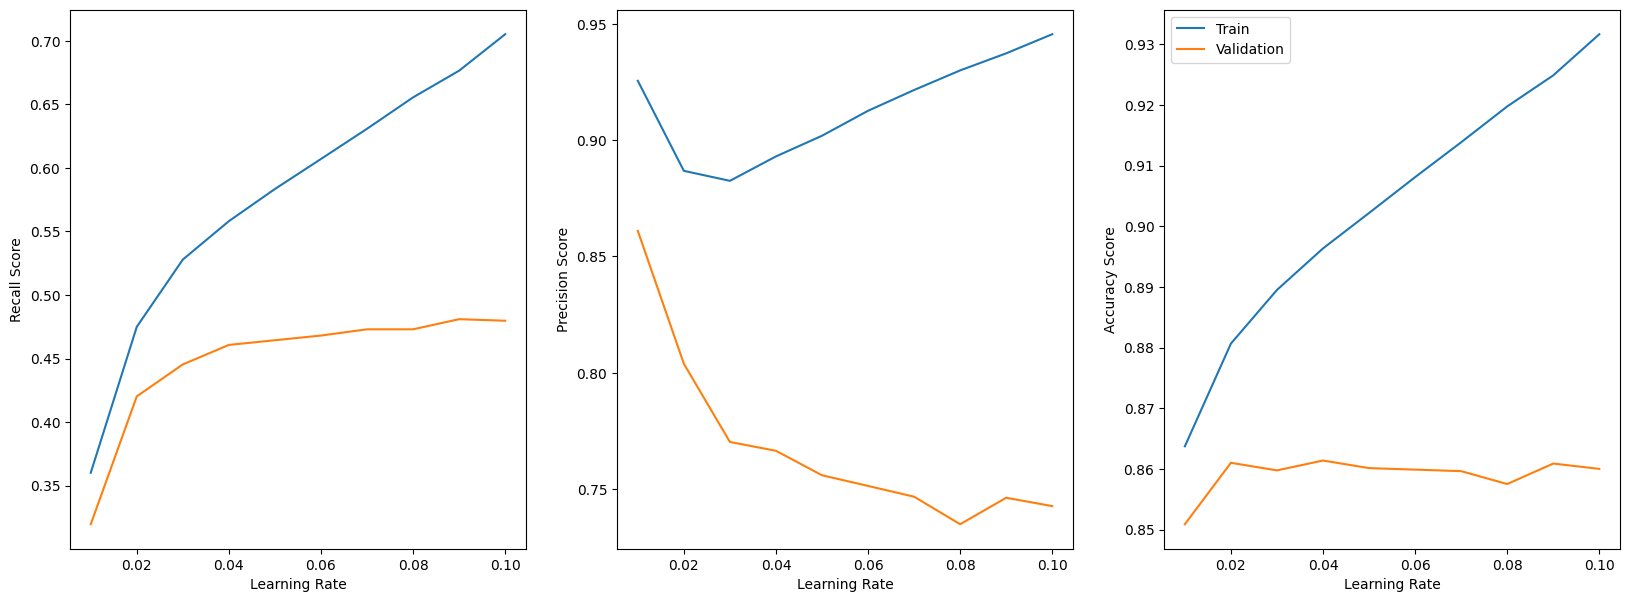

In [81]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [82]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")

,param_gradientboostingclassifier__learning_rate,mean_test_recall,mean_train_recall,rank_test_recall,mean_test_accuracy,mean_train_accuracy,mean_test_precision,mean_train_precision
0,0.01,0.319632,0.360123,10,0.850875,0.863719,0.861005,0.925488
1,0.02,0.420245,0.475000,9,0.861000,0.880656,0.803909,0.886796
2,0.03,0.445399,0.527914,8,0.859750,0.889500,0.770306,0.882506
3,0.04,0.460736,0.558129,7,0.861375,0.896344,0.766500,0.892998
4,0.05,0.464417,0.583436,6,0.860125,0.902187,0.755984,0.901879
5,0.06,0.468098,0.607055,5,0.859875,0.908094,0.751409,0.912613
6,0.07,0.473006,0.630828,3,0.859625,0.913844,0.746777,0.921537
7,0.08,0.473006,0.655521,3,0.857500,0.919750,0.734950,0.929960
8,0.09,0.480982,0.676534,1,0.860875,0.924875,0.746319,0.937298
9,0.10,0.479755,0.705215,2,0.860000,0.931656,0.742732,0.945506


#### Retrain the model with learning rate of 0.02

In [83]:
# Instantiate the model

gb_model = GradientBoostingClassifier(max_depth=6, learning_rate=0.02, random_state=42)

In [84]:
# Create pipeline

pipeline = make_pipeline(category_transformer, gb_model)
pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=0.02, max_depth=6,
                                            random_state=42))])

#### Evaluate the training set

In [85]:
gb_train_errors = get_errors(pipeline, X_train, y_train)
gb_train_errors

{'accuracy': 0.878375,
 'recall': np.float64(0.4662576687116564),
 'precision': np.float64(0.880648899188876)}

#### Evaluate with cross validation

In [86]:
cv_results = cross_validate(pipeline, X_train, y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.8608750000000001),
 'recall': np.float64(0.4190184049079755),
 'precision': np.float64(0.8045940847586515)}

#### Evaluate on test

In [87]:
gb_test_errors = get_errors(pipeline, X_test, y_test)
gb_test_errors

{'accuracy': 0.866,
 'recall': np.float64(0.4176904176904177),
 'precision': np.float64(0.845771144278607)}

#### Log errors

In [88]:
log_error("Opt GB Model", gb_train_errors.values(), "train")
log_error("Opt GB Model", gb_avg_cv_errors.values(), "cv")
log_error("Opt GB Model", gb_test_errors.values(), "test")

In [89]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938
DT Model,0.868125,0.459509,0.811484,0.856125,0.404294,0.782881,0.8595,0.44226,0.769231
RF Model,0.867,0.399387,0.884511,0.857875,0.383436,0.826891,0.8605,0.373464,0.863636
GB Model,0.923625,0.672393,0.934356,0.86,0.479755,0.742732,0.8625,0.476658,0.757812
Opt GB Model,0.878375,0.466258,0.880649,0.860875,0.419018,0.804594,0.866,0.41769,0.845771


### Plot optimal GB confusion matrix

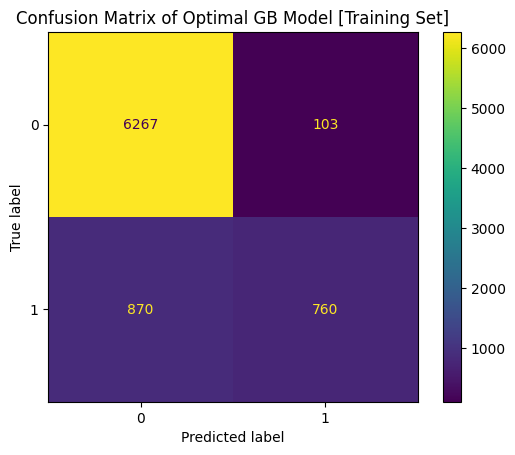

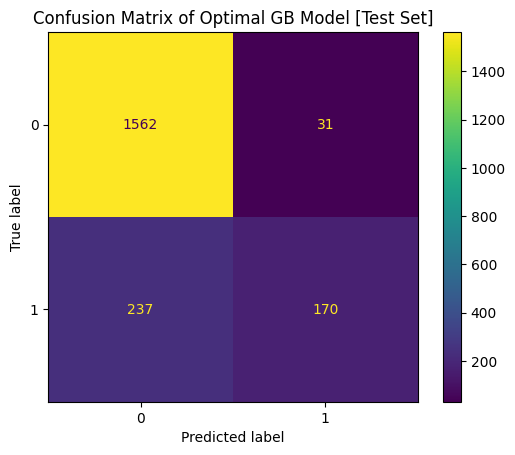

In [90]:
plot_confusion_matrix(pipeline, "Optimal GB", X_train, X_test, y_train, y_test)

#### Add kmeans features to GB model

In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [92]:
# Build custom kmeans transformer

class CustomKMeans(KMeans):
    def get_feature_names_out(self):
        feats = ["cluster_label"] + [f"dist_{i}" for i in range(self.n_clusters)]
        return feats
    
    def transform(self, X):
        return self._transform(X)
    
    def _transform(self, X):
        distances =  super()._transform(X)
        labels = self.predict(X)
        return np.hstack((labels.reshape(-1, 1), distances))

In [93]:
kmean_pipe = make_pipeline(
    category_transformer,
    StandardScaler(),
    CustomKMeans(4, random_state=42)
)

In [94]:
preprocessor_pipe = make_pipeline(
    FeatureUnion(
        [
            ("cat_encoder", category_transformer),
            ("kmeans", kmean_pipe),
        ],
    ),
    ColumnTransformer(
        [("kmeans_cat_encoder", OneHotEncoder(sparse_output=False), ["cluster_label"])],
        verbose_feature_names_out=False,
        remainder="passthrough",
    ),
)

In [95]:
gb_kmeans_pipeline = make_pipeline(
    preprocessor_pipe,
    gb_model
)

In [96]:
gb_kmeans_pipeline.fit(X_train, y_train)

/home/tiloye/projects/churn_prediction/.venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('featureunion',
                                  FeatureUnion(transformer_list=[('cat_encoder',
                                                                  ColumnTransformer(remainder='passthrough',
                                                                                    transformers=[('cat_encoder',
                                                                                                   OneHotEncoder(drop='if_binary',
                                                                                                                 sparse_output=False),
                                                                                                   ['country',
                                                                                                    'gender'])],
                                                                                    verbose_feature_names_out=False)),
                                                                 ('kmeans',
                                                                  Pipeline(steps=[('columntransformer',
                                                                                   ColumnTransformer...
                                                                                  ('customkmeans',
                                                                                   CustomKMeans(n_clusters=4,
                                                                                                random_state=42))]))])),
                                 ('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('kmeans_cat_encoder',
                                                                   OneHotEncoder(sparse_output=False),
                                                                   ['cluster_label'])],
                                                    verbose_feature_names_out=False))])),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=0.02, max_depth=6,
                                            random_state=42))])

#### Evaluate the training set

In [97]:
gb_train_errors = get_errors(gb_kmeans_pipeline, X_train, y_train)
gb_train_errors

{'accuracy': 0.881375,
 'recall': np.float64(0.47791411042944787),
 'precision': np.float64(0.8882554161915621)}

#### Evaluate with cross validation

In [98]:
cv_results = cross_validate(gb_kmeans_pipeline, X_train, y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.85975),
 'recall': np.float64(0.4184049079754601),
 'precision': np.float64(0.7981506837223392)}

#### Evaluate on test

In [99]:
gb_test_errors = get_errors(gb_kmeans_pipeline, X_test, y_test)
gb_test_errors

{'accuracy': 0.864,
 'recall': np.float64(0.4275184275184275),
 'precision': np.float64(0.8169014084507042)}

#### Log errors

In [100]:
log_error("Opt GB+KM Model", gb_train_errors.values(), "train")
log_error("Opt GB+KM Model", gb_avg_cv_errors.values(), "cv")
log_error("Opt GB+KM Model", gb_test_errors.values(), "test")

In [101]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.79625,0.0,0.0,0.79625,0.0,0.0,0.7965,0.0,0.0
LR Model,0.810875,0.214724,0.600343,0.810125,0.213497,0.595239,0.8075,0.184275,0.585938
DT Model,0.868125,0.459509,0.811484,0.856125,0.404294,0.782881,0.8595,0.44226,0.769231
RF Model,0.867,0.399387,0.884511,0.857875,0.383436,0.826891,0.8605,0.373464,0.863636
GB Model,0.923625,0.672393,0.934356,0.86,0.479755,0.742732,0.8625,0.476658,0.757812
Opt GB Model,0.878375,0.466258,0.880649,0.860875,0.419018,0.804594,0.866,0.41769,0.845771
Opt GB+KM Model,0.881375,0.477914,0.888255,0.85975,0.418405,0.798151,0.864,0.427518,0.816901


## Plot Confusion Matrix of GB_KM model

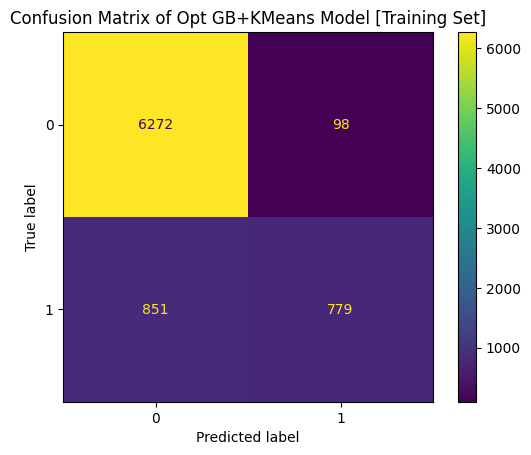

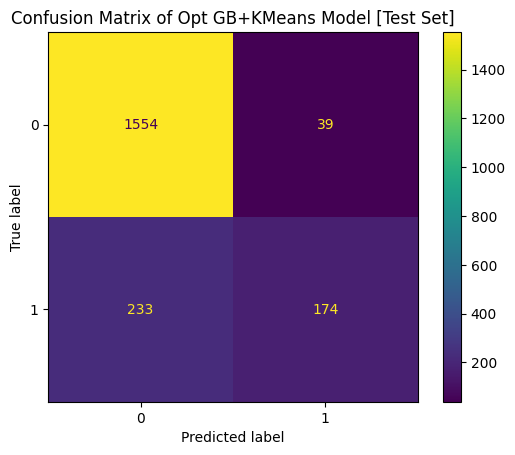

In [102]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_train, X_test, y_train, y_test)

## Visualize feature importance

In [103]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=gb_kmeans_pipeline[-1].feature_names_in_,
).sort_values()

In [104]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

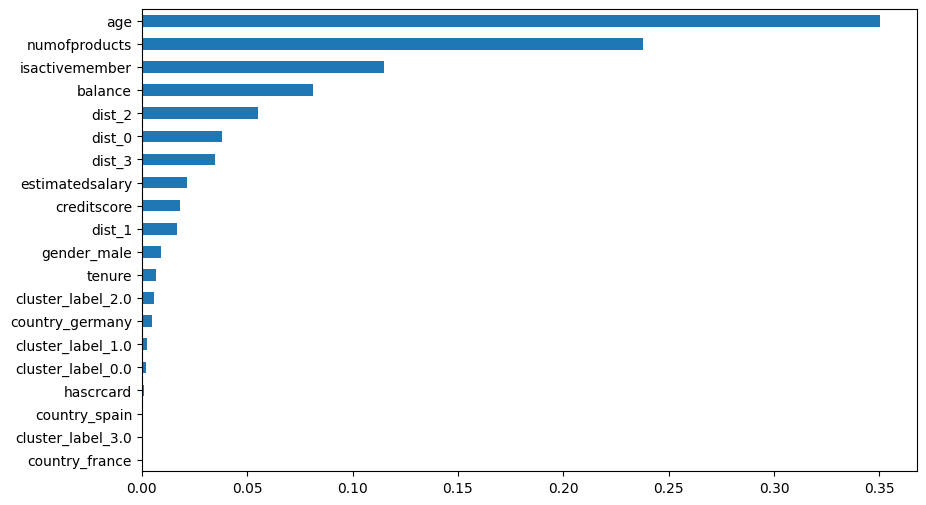

In [105]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

Age and number of products seems to be the most significant feature for determing customers who are likely to leave. The KMeans distance feature seems to be more important than the cluster labels, and the country features.

## Plot precision recall curve

In [106]:
from sklearn.metrics import precision_recall_curve

In [107]:
precision, recall, thresholds = precision_recall_curve(y_test, gb_kmeans_pipeline.predict_proba(X_test)[:, 1])

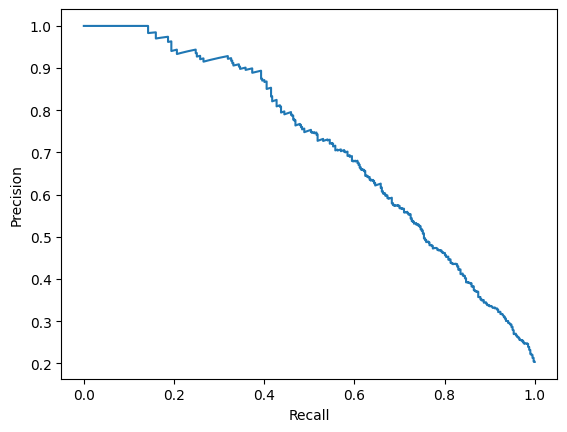

In [108]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision");

## Find optimal probability threshold

In [109]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [110]:
ttcv = TunedThresholdClassifierCV(gb_kmeans_pipeline, cv=5)
ttcv.fit(X_train, y_train)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('pipeline',
                                                      Pipeline(steps=[('featureunion',
                                                                       FeatureUnion(transformer_list=[('cat_encoder',
                                                                                                       ColumnTransformer(remainder='passthrough',
                                                                                                                         transformers=[('cat_encoder',
                                                                                                                                        OneHotEncoder(drop='if_binary',
                                                                                                                                                      sparse_output=False),
                                                                                                                                        ['country',
                                                                                                                                         'gender'])],
                                                                                                                         verbose_feature_names_out=False)),
                                                                                                      ('kmeans',
                                                                                                       Pipeline(ste...
                                                                                                                       ('customkmeans',
                                                                                                                        CustomKMeans(n_clusters=4,
                                                                                                                                     random_state=42))]))])),
                                                                      ('columntransformer',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('kmeans_cat_encoder',
                                                                                                        OneHotEncoder(sparse_output=False),
                                                                                                        ['cluster_label'])],
                                                                                         verbose_feature_names_out=False))])),
                                                     ('gradientboostingclassifier',
                                                      GradientBoostingClassifier(learning_rate=0.02,
                                                                                 max_depth=6,
                                                                                 random_state=42))]))

In [111]:
get_errors(ttcv, X_train, y_train)

{'accuracy': 0.8315,
 'recall': np.float64(0.8085889570552147),
 'precision': np.float64(0.5598980458793543)}

In [112]:
ttcv.best_threshold_

np.float64(0.20011262169512345)

In [113]:
ttcv.best_score_

np.float64(0.7746716003975813)

In [114]:
get_errors(ttcv, X_test, y_test)

{'accuracy': 0.8045,
 'recall': np.float64(0.7518427518427518),
 'precision': np.float64(0.5134228187919463)}

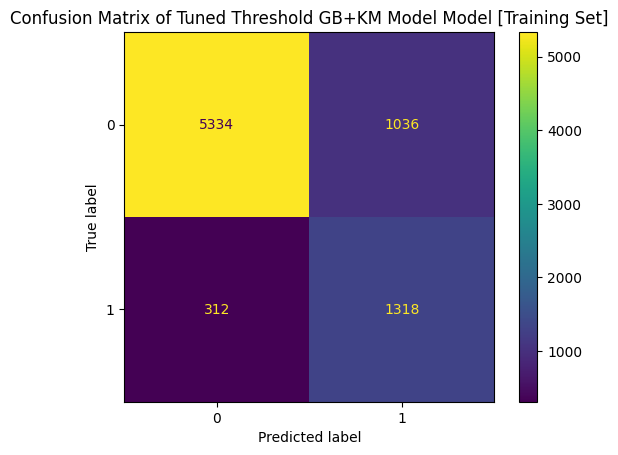

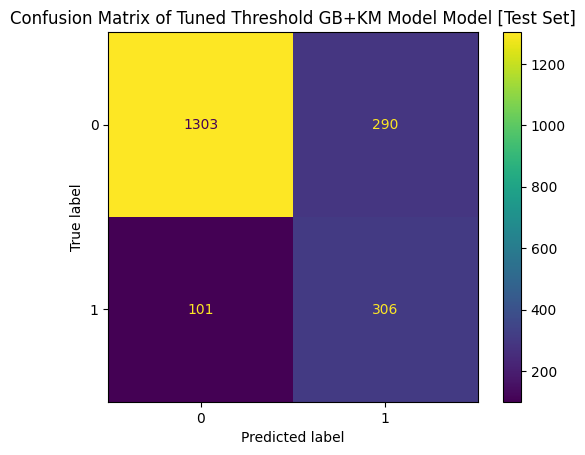

In [115]:
plot_confusion_matrix(ttcv, "Tuned Threshold GB+KM Model", X_train, X_test, y_train, y_test)

### Save the model

In [116]:
import joblib

In [117]:
joblib.dump(ttcv, "../models/churn_model_v1.pkl")

['../models/churn_model_v1.pkl']

## Load and test the model

In [118]:
model = joblib.load("../models/churn_model_v1.pkl")

In [119]:
get_errors(model, X, y)

{'accuracy': 0.8261,
 'recall': np.float64(0.7972508591065293),
 'precision': np.float64(0.5505084745762712)}